In [1]:
import yfinance as yf 

In [2]:
msft_ticker = 'MSFT'
df_MSFT = yf.download(tickers=msft_ticker, multi_level_index=False)
df_MSFT

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
1986-03-13,0.059598,0.062259,0.054277,0.054277,1031788800
1986-03-14,0.061726,0.062791,0.059598,0.059598,308160000
1986-03-17,0.062791,0.063323,0.061726,0.061726,133171200
1986-03-18,0.061194,0.063323,0.060662,0.062791,67766400
1986-03-19,0.060130,0.061726,0.059598,0.061194,47894400
...,...,...,...,...,...
2025-05-19,458.869995,459.589996,450.799988,450.880005,21336500
2025-05-20,458.170013,458.339996,454.320007,455.589996,15441800
2025-05-21,452.570007,457.779999,451.809998,454.570007,19216900


In [3]:
btc_ticker = 'BTC-USD'
df_BTC = yf.download(tickers=btc_ticker, multi_level_index=False)
df_BTC

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100
...,...,...,...,...,...
2025-05-23,107287.796875,111798.906250,106841.304688,111679.359375,67548133399
2025-05-24,107791.156250,109454.523438,106895.289062,107278.507812,45903627163
2025-05-25,109035.390625,109313.304688,106683.375000,107802.273438,47518041841


In [4]:
import sys 
print(sys.executable)

c:\Users\thelm\AppData\Local\Programs\Python\Python313\python.exe


In [5]:
import ensurepip 
ensurepip.bootstrap()

In [6]:
!pip install --upgrade pip

In [7]:
#!"{sys.executable}" -m pip install plotly
!"{sys.executable}"  pip install -U plotly

c:\Users\thelm\AppData\Local\Programs\Python\Python313\python.exe: can't open file 'c:\\Users\\thelm\\Personal-dev\\Python-For-Finance\\algo-trading-with-ml\\pip': [Errno 2] No such file or directory


In [8]:
df_MSFT

,Close,High,Low,Open,Volume
Date,,,,,
1986-03-13,0.059598,0.062259,0.054277,0.054277,1031788800
1986-03-14,0.061726,0.062791,0.059598,0.059598,308160000
1986-03-17,0.062791,0.063323,0.061726,0.061726,133171200
1986-03-18,0.061194,0.063323,0.060662,0.062791,67766400
1986-03-19,0.060130,0.061726,0.059598,0.061194,47894400
...,...,...,...,...,...
2025-05-19,458.869995,459.589996,450.799988,450.880005,21336500
2025-05-20,458.170013,458.339996,454.320007,455.589996,15441800
2025-05-21,452.570007,457.779999,451.809998,454.570007,19216900


In [9]:
import plotly.graph_objects as go

df = df_MSFT 

fig = go.Figure(data=[go.Candlestick(x=df.index, 
open=df['Open'], 
high=df['High'], 
low=df['Low'], 
close=df['Close'])])

fig.show()

#have to set multi_level_index to false when downloading to prevent 
#multi-level columns witht he company name on the top being retrieved 


In [10]:
df2 = df_BTC
fig = go.Figure(data=[go.Candlestick(x=df2.index,
open=df2['Open'],
high=df2['High'],
low=df2['Low'],
close=df2['Close'])])

fig.show()

In [11]:
!"{sys.executable}" -m pip install openpyxl


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import openpyxl

In [13]:
# exporting the data 
# dropping adj to not confuse w close price 
#df_MSFT = df_MSFT.drop(columns='Adj Close') - not needed 

#export to excel - have to create folder called data first in cureent directory 
df_MSFT.to_excel('data/Microsoft_Stock_Price_Historical_Daily_Wihtout_Adj_Close.xlsx')

#export to csv - less memory 
df_MSFT.to_csv('data/Microsoft_Stock_Price_Historical_Daily_Wihtout_Adj_Close.csv')

In [14]:
#doign everything w bTC 
file_path = f'data/{btc_ticker}.xlsx'
file_path 

#export to excel 
df_BTC.to_excel(file_path)

#export to csv 
df_BTC.to_csv(f'data/{btc_ticker}.csv')

In [15]:
'''code to acess any data from yfinance and export to excel and csv 
ticker = 'MSFT' # or 'BTC-USD' for Bitcoin
df = yf.download(tickers=ticker)
df.to_excel(f'data/{ticker}.xlsx')
df.to_csv(f'data/{ticker}.csv')
'''

"code to acess any data from yfinance and export to excel and csv \nticker = 'MSFT' # or 'BTC-USD' for Bitcoin\ndf = yf.download(tickers=ticker)\ndf.to_excel(f'data/{ticker}.xlsx')\ndf.to_csv(f'data/{ticker}.csv')\n"

### Filter rows and create columns for trading strategies 

In [16]:
import pandas as pd 

df_microsoft = pd.read_excel('data/Microsoft_Stock_Price_Historical_Daily_Wihtout_Adj_Close.xlsx', 
parse_dates=['Date'],
index_col=0)

df_microsoft

#microsoft acquired linkedin: 8th dec 2016 - $26.2 billion

,Close,High,Low,Open,Volume
Date,,,,,
1986-03-13,0.059598,0.062259,0.054277,0.054277,1031788800
1986-03-14,0.061726,0.062791,0.059598,0.059598,308160000
1986-03-17,0.062791,0.063323,0.061726,0.061726,133171200
1986-03-18,0.061194,0.063323,0.060662,0.062791,67766400
1986-03-19,0.060130,0.061726,0.059598,0.061194,47894400
...,...,...,...,...,...
2025-05-19,458.869995,459.589996,450.799988,450.880005,21336500
2025-05-20,458.170013,458.339996,454.320007,455.589996,15441800
2025-05-21,452.570007,457.779999,451.809998,454.570007,19216900


In [17]:
#filter the rows and columns using loc to idneifty what we want 
#rows from 2016-12-08 onwards and all columns 
df_microsoft_from_linkedin_acquisition = df_microsoft.loc['2016-12-08':, :]
df_microsoft_from_linkedin_acquisition

,Close,High,Low,Open,Volume
Date,,,,,
2016-12-08,55.079998,55.594599,54.926523,55.341812,21220800
2016-12-09,55.946697,55.964754,55.188343,55.233482,27349400
2016-12-12,56.127254,56.244620,55.720996,55.811275,20198100
2016-12-13,56.858536,57.255768,56.190463,56.425191,35718900
2016-12-14,56.587692,57.282851,56.452270,56.876589,30352700
...,...,...,...,...,...
2025-05-19,458.869995,459.589996,450.799988,450.880005,21336500
2025-05-20,458.170013,458.339996,454.320007,455.589996,15441800
2025-05-21,452.570007,457.779999,451.809998,454.570007,19216900


In [18]:
#compute if stock inc / dec - have to calc the daily diff based on the close price 
#seldct column close as clac daily diff based on close price 
df_microsoft_from_linkedin_acquisition.Close

Date
2016-12-08     55.079998
2016-12-09     55.946697
2016-12-12     56.127254
2016-12-13     56.858536
2016-12-14     56.587692
                 ...    
2025-05-19    458.869995
2025-05-20    458.170013
2025-05-21    452.570007
2025-05-22    454.859985
2025-05-23    450.179993
Name: Close, Length: 2126, dtype: float64

In [19]:
#daily diff is the same as percentage chnage thf use pct_change func
# func so ha to eb called - ()
df_microsoft_from_linkedin_acquisition.Close.pct_change()

Date
2016-12-08         NaN
2016-12-09    0.015735
2016-12-12    0.003227
2016-12-13    0.013029
2016-12-14   -0.004763
                ...   
2025-05-19    0.010126
2025-05-20   -0.001525
2025-05-21   -0.012223
2025-05-22    0.005060
2025-05-23   -0.010289
Name: Close, Length: 2126, dtype: float64

In [20]:
#make it easier to understand by * 100
df_microsoft_from_linkedin_acquisition.Close.pct_change() * 100
#stock inc 1.57 % from 8th to 9th dec 2016

Date
2016-12-08         NaN
2016-12-09    1.573528
2016-12-12    0.322731
2016-12-13    1.302899
2016-12-14   -0.476346
                ...   
2025-05-19    1.012615
2025-05-20   -0.152545
2025-05-21   -1.222255
2025-05-22    0.505994
2025-05-23   -1.028886
Name: Close, Length: 2126, dtype: float64

In [21]:
#calc what will happen tomorrow based on today's data, need to shift the pct column backwrds 
df_microsoft_from_linkedin_acquisition.Close.pct_change(-1) * 100 
#this shows that stock is dec, then it's actuallly inc thf have to multiply by -1 

Date
2016-12-08   -1.549152
2016-12-09   -0.321693
2016-12-12   -1.286142
2016-12-13    0.478626
2016-12-14    0.159799
                ...   
2025-05-19    0.152778
2025-05-20    1.237379
2025-05-21   -0.503447
2025-05-22    1.039583
2025-05-23         NaN
Name: Close, Length: 2126, dtype: float64

In [22]:
df_microsoft_from_linkedin_acquisition.Close.pct_change(-1) * 100 * -1

Date
2016-12-08    1.549152
2016-12-09    0.321693
2016-12-12    1.286142
2016-12-13   -0.478626
2016-12-14   -0.159799
                ...   
2025-05-19   -0.152778
2025-05-20   -1.237379
2025-05-21    0.503447
2025-05-22   -1.039583
2025-05-23         NaN
Name: Close, Length: 2126, dtype: float64

In [24]:
#save to new var 
df_microsoft_from_linkedin_acquisition['change_tomorrow'] = df_microsoft_from_linkedin_acquisition.Close.pct_change(-1) * 100 * -1

C:\Users\thelm\AppData\Local\Temp\ipykernel_17832\3511576327.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [25]:
df_microsoft_from_linkedin_acquisition

,Close,High,Low,Open,Volume,change_tomorrow
Date,,,,,,
2016-12-08,55.079998,55.594599,54.926523,55.341812,21220800,1.549152
2016-12-09,55.946697,55.964754,55.188343,55.233482,27349400,0.321693
2016-12-12,56.127254,56.244620,55.720996,55.811275,20198100,1.286142
2016-12-13,56.858536,57.255768,56.190463,56.425191,35718900,-0.478626
2016-12-14,56.587692,57.282851,56.452270,56.876589,30352700,-0.159799
...,...,...,...,...,...,...
2025-05-19,458.869995,459.589996,450.799988,450.880005,21336500,-0.152778
2025-05-20,458.170013,458.339996,454.320007,455.589996,15441800,-1.237379
2025-05-21,452.570007,457.779999,451.809998,454.570007,19216900,0.503447


In [27]:
#drop last row as it there's no future day to calc the change_tomorrow for
df_microsoft_from_linkedin_acquisition = df_microsoft_from_linkedin_acquisition.dropna().copy()


In [30]:
#see if stocks whent up or down 
import numpy as np 

#if chnage_tromorrow > 0 = up, otherwise down 
df_microsoft_from_linkedin_acquisition['change_tomorrow_direction'] = np.where(df_microsoft_from_linkedin_acquisition.change_tomorrow > 0 , 'UP', 'DOWN')

In [32]:
df_microsoft_from_linkedin_acquisition


,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,55.079998,55.594599,54.926523,55.341812,21220800,1.549152,UP
2016-12-09,55.946697,55.964754,55.188343,55.233482,27349400,0.321693,UP
2016-12-12,56.127254,56.244620,55.720996,55.811275,20198100,1.286142,UP
2016-12-13,56.858536,57.255768,56.190463,56.425191,35718900,-0.478626,DOWN
2016-12-14,56.587692,57.282851,56.452270,56.876589,30352700,-0.159799,DOWN
...,...,...,...,...,...,...,...
2025-05-16,454.269989,454.359985,448.730011,452.049988,23849800,1.002464,UP
2025-05-19,458.869995,459.589996,450.799988,450.880005,21336500,-0.152778,DOWN
2025-05-20,458.170013,458.339996,454.320007,455.589996,15441800,-1.237379,DOWN


In [35]:
#observe distribution of ups and downs 
df_microsoft_from_linkedin_acquisition.change_tomorrow_direction.value_counts()

change_tomorrow_direction
UP      1147
DOWN     978
Name: count, dtype: int64

<Axes: xlabel='Date'>

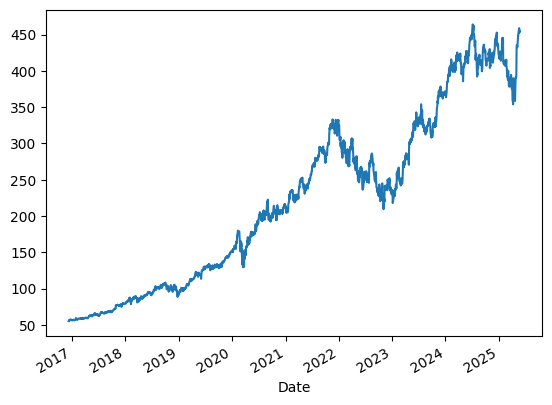

In [36]:
df_microsoft_from_linkedin_acquisition.Close.plot()

In [37]:
df_microsoft_from_linkedin_acquisition.to_excel('data/Microsoft_LinkedIn_Processed.xlsx')